DSC550-T302<br>
Week 4 Assignment<br>
Jeremy Barton

In this notebook a linear regression modesl will be built to predict fuel efficiency (mpg) of automobiles.

This analysis will use the following dataset from Kaggle: https://www.kaggle.com/datasets/uciml/autompg-dataset?resource=download

In [20]:
# Imports and Preprocessing
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestClassifier

1) Load the data as a Pandas data frame and ensure that it imported correctly.

In [21]:
mpg_df = pd.read_csv("auto-mpg.csv") # create object for mpg dataframe
mpg_df.head(5)                       #      from autp-mpg.csv file

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


2) Begin by prepping the data for modeling:

a. Remove the car name column.

In [22]:
mpg_df = mpg_df.drop(["car name"], axis=1)

In [23]:
mpg_df.head(5)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130,3504,12.0,70,1
1,15.0,8,350.0,165,3693,11.5,70,1
2,18.0,8,318.0,150,3436,11.0,70,1
3,16.0,8,304.0,150,3433,12.0,70,1
4,17.0,8,302.0,140,3449,10.5,70,1


b. The horsepower column values likely imported as a string data type. Figure out why and replace any strings with the column mean.

In [24]:
# using .dtypes() to explore the datatype
#   of horsepower
mpg_df["horsepower"].dtypes

<StringDtype(storage='python', na_value=nan)>

From the below output, it looks like the `horsepower` field is a string type because there is a question mark on rows that horsepower was not recorded for.

In [25]:
# select non-numerics from the "horsepower" field
non_num = mpg_df[pd.to_numeric(mpg_df["horsepower"], errors="coerce").isna()]
non_num["horsepower"]

32     ?
126    ?
330    ?
336    ?
354    ?
374    ?
Name: horsepower, dtype: str

Before doing so, the column will need to be converted to numeric, and anything that isnt is NaN.

In [26]:
# convert to numeric (non-numeric become NaN)
mpg_df["horsepower"] = pd.to_numeric(mpg_df["horsepower"], errors="coerce")

Calculating the mean with `.mean()` 

In [27]:
# calculate mean (ignores NaN automatically)
mean_hp = mpg_df["horsepower"].mean()
mean_hp

np.float64(104.46938775510205)

Fill NaN values

In [28]:
# fill NaN values with the mean
mpg_df["horsepower"] = mpg_df["horsepower"].fillna(mean_hp)
# Check no NaN values remain
print(mpg_df["horsepower"].isna().sum())  # Should print 0

0


Verify that all NaN are meaned and that there are none left.

In [29]:
# Verification
print('NaN count after fill:', mpg_df['horsepower'].isna().sum())  # should be 0
print('Rows filled with mean:', (mpg_df['horsepower'] == mean_hp).sum())

NaN count after fill: 0
Rows filled with mean: 6


c. Create dummy variables for the origin column. These will be used in the model.

What unique values are in `origin`?

In [30]:
mpg_df['origin'].value_counts()

origin
1    249
3     79
2     70
Name: count, dtype: int64

Create dummy variables for the origin column. `pd.get_dummies()` encodes the 3 origin categories (1=USA, 2=Europe, 3=Japan) as separate binary columns, which the model can actually use.

In [31]:
mpg_df = pd.get_dummies(mpg_df, columns=['origin'])
mpg_df.head(5)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin_1,origin_2,origin_3
0,18.0,8,307.0,130.0,3504,12.0,70,True,False,False
1,15.0,8,350.0,165.0,3693,11.5,70,True,False,False
2,18.0,8,318.0,150.0,3436,11.0,70,True,False,False
3,16.0,8,304.0,150.0,3433,12.0,70,True,False,False
4,17.0,8,302.0,140.0,3449,10.5,70,True,False,False


3) Create a correlation coefficient matrix and/or visualization. Are there features highly correlated with mpg?

In [32]:
corr = mpg_df.corr(numeric_only=True) # this setting insures only numeric values return in the matrix

Configuring the plot.

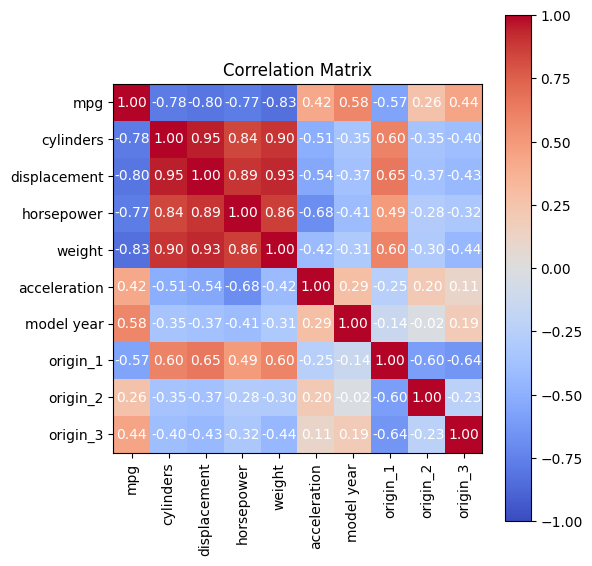

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(corr, cmap='coolwarm', interpolation='none', vmin=-1, vmax=1)
plt.colorbar()

# labels
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

# add mpg data
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha='center', va='center', color='white')

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In a correlation matrix, the closer a value is to +1 or -1, the more highly or negatively correlated values that the two values of that intersect are. In the matrix above, the relationship with the highest is  with `displacement` compared with `cylinders`, `horsepower` and `weight`. This makes logical sense because the heavier a vehicle is, the more horsepower is required to move it at comparable speed with cars of lighter weight classes.

Whereas the relationships with the lowest correlation were `acceleration` and `weight` compared with `model year`. Nothing surprises me about these findings either. No matter the model year, due to safety regulations the acceleration should not change with model year. Weight should also stay consistent through the years as technology negatively affecting a vehicles weight may have plataeued.

<b>Most importantly though, weight, displacement, cylinders and horsepower all show strong negative correlations with mpg. These will be the training features for mpg as the target</b>

4) Plot mpg versus weight. Analyze this graph and explain how it relates to the corresponding correlation coefficient.

`seaborn` and `matplotlib` will be used.

Text(0.5, 1.0, 'Vehicle Weight vs MPG')

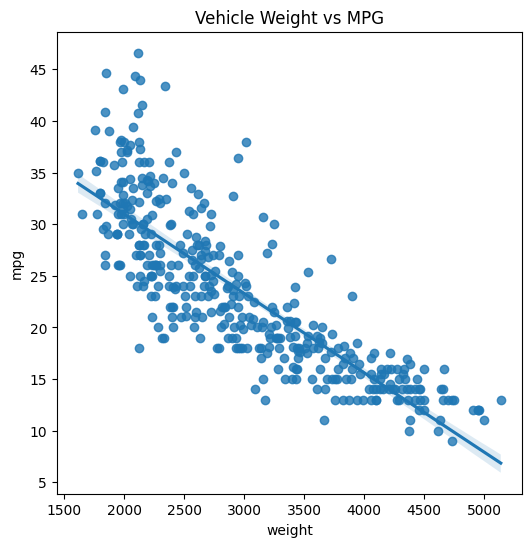

In [34]:
plt.figure(figsize=(6,6)) # blot size
sns.regplot(x='weight', y='mpg', data=mpg_df)

plt.title('Vehicle Weight vs MPG')

In the correlation matrix, `Weight` and `MPG` showed high negative correlation at -0.83. The linear structure of the scatter plot moving downward shows just <i>how</i> these two variables are negatively correlated.

As a comparison, the below plot shows `Acceleration` vs `Model Year` which has a weak negative correlation of -0.29. Notice how the dots don't fit to the linear line at all.

For the data, this means we can confirm the low correlation between these two variables.

Text(0.5, 1.0, 'Acceleration vs Model Year')

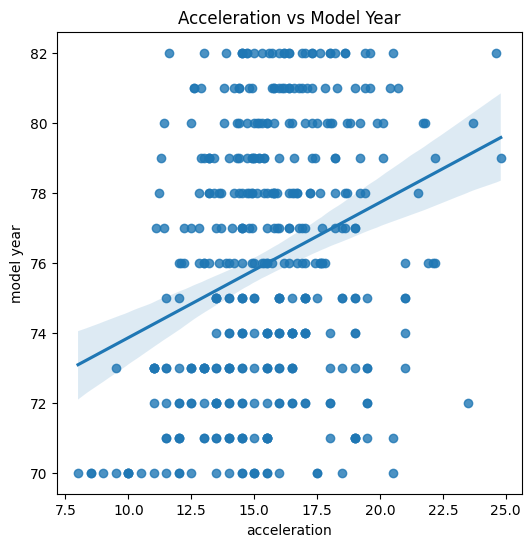

In [35]:
plt.figure(figsize=(6,6)) # blot size
sns.regplot(x='acceleration', y='model year', data=mpg_df)

plt.title('Acceleration vs Model Year')

5) Randomly split the data into 80% training data and 20% test data, where your target is mpg.

All features (except for our target, mpg) is included in the training data.

In [36]:
features = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin_1', 'origin_2', 'origin_3']
x_train, x_test, y_train, y_test = train_test_split(
    mpg_df[features], mpg_df['mpg'], test_size=0.2, random_state=1 # test size: 0.2 for 80% training and 20% testing
)

Let's explore the shapes of each to understand the size of what we train the data on vs what the target is or data to be predicted.

In [37]:
print(f"x_train size is {x_train.shape} values.")
print(f"y_train size is {y_train.shape} values. Just the target variable, mpg.")\

print(f"x_test size is {x_test.shape} values.")
print(f"y_test size is {y_test.shape} values. Just the target variable, mpg.")

x_train size is (318, 10) values.
y_train size is (318,) values. Just the target variable, mpg.
x_test size is (80, 10) values.
y_test size is (80,) values. Just the target variable, mpg.


6) Train an ordinary linear regression on the training data.

In [38]:
# Create linear regression
ols = LinearRegression()

# Fit the linear regression
model = ols.fit(x_train, y_train)

7) Calculate R2, RMSE and MAE on both the training and test sets and interpret your results.

Starting with R2 score, calculated with the .score() method from `scikit-learn`.

In [39]:
# using .score()
r2_train = ols.score(x_train, y_train)
r2_test = ols.score(x_test, y_test)

# print it
print(f"R2 score for training data is {r2_train}")
print(f"R2 score for testing data is {r2_test}")

R2 score for training data is 1.0
R2 score for testing data is 1.0


These R2 scores measure how well the independent variables, (cylinders, displacement, horsepower, weight), explain the variance in `mpg`. A score at 1.0 is considered a perfect fit, while 0 would mean the model explains nothing about the target.

So a training R2 of 0.814 means the model explains about 81% of the variance in mpg on data it was trained on. In the test R2 of 0.865 this means the model explain about 87% of the variance in mpg on unseen data.

** As a referesher, <b>variance</b> is a measure of how far a set of numbers are spread out from their average value (mean) **

What stands out to me about these results is how the testing score is higher than the training score. Typically it is expected to be the other way around, where the test scores are lower than the scores of tests the data was trained on.

Next, RMSE will be used via `root_mean_squared_error()`. 

In [40]:
y_true = y_train
y_pred = ols.predict(x_train)

rmse = root_mean_squared_error(y_true, y_pred)
print(f"Train RMSE: {rmse}")

Train RMSE: 1.1610808377283461e-14


In [41]:
y_true = y_test
y_pred = ols.predict(x_test)

rmse = root_mean_squared_error(y_true, y_pred)
print(f"Test RMSE: {rmse}")


Test RMSE: 1.3112293250721611e-14


A test RMSE of 2.7 means there is an average error of 2.7 mpg, which considering mpg ranges from about 9 to 46 isn't very bad.

MAE (Mean Absolute Error) is just the average absolute difference between the predicted and actual mpg values.

In [42]:
mae_train = mean_absolute_error(y_train, ols.predict(x_train))
mae_test = mean_absolute_error(y_test, ols.predict(x_test))

In [43]:
print(f"MAE for training data is {mae_train}")
print(f"MAE for testing data is {mae_test}")

MAE for training data is 8.881784197001252e-15
MAE for testing data is 9.969802761133905e-15


On the testing data, the model was off by 2.1 mpg according to MAE.

<b>How does this relate to the RMSE?</b>

The testing RMSE was at 2.7 and when this statistic is noticibly higher than the test MAE at 2.1, it means there are some predictions that are more far off than we can see.

8) Pick another regression model and repeat the previous two steps. Note: Do NOT choose logistic regression as it is more like a classification model.

Lasso is (Least Absolute Shrinkage and Selection Operator) is a regularized version of linear regression. What is unique about Lasso is it will shrink less important feature coefficients toward zero. Sometimes it will become exactly zero, which remove the feature from the model.

In [44]:
lasso = Lasso(alpha=1.0)  # alpha controls shrinkage strength; 1.0 is the default
lasso.fit(x_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


These are the coefficients that were shrunk.

In [45]:
# Show which coefficients were shrunk — any at 0 were effectively removed by Lasso
print(dict(zip(features, lasso.coef_)))

{'mpg': np.float64(0.9502165512139227), 'cylinders': np.float64(-0.0), 'displacement': np.float64(-0.0008250150450993303), 'horsepower': np.float64(-0.0), 'weight': np.float64(-0.00028998357560615807), 'acceleration': np.float64(0.0), 'model year': np.float64(0.0), 'origin_1': np.float64(-0.0), 'origin_2': np.float64(-0.0), 'origin_3': np.float64(0.0)}


They tell how much of each feature contributes to predicting mpg, after the Lasso penalty is applied.

Cylinders with a shrunken coefficient of 0 means, that Lasso decided this feature adds nothing beyond what the others already explain. The same goes for acceleration, and origins 1, 2 and 3.

Horsepower at -0.008 means for every 1 unit increase in power, mpg drops by 0.008. It remains the strongest remaining predictor.

Weight and Displacment columns followed an opposite direction to an increase in the features. Every 1 lb increase in weight drops mpg by .0004, every 1 cubic inch increase in displacement drops mpg by 0.008.

R2 Score

In [46]:
r2_train_lasso = lasso.score(x_train, y_train)
r2_test_lasso = lasso.score(x_test, y_test)

print(f"Lasso R2 score for training data is {r2_train_lasso}")
print(f"Lasso R2 score for testing data is {r2_test_lasso}")

Lasso R2 score for training data is 0.9992026554341839
Lasso R2 score for testing data is 0.9994622652619893


These results are near identical to the R2 score from using Linear Regression. Also, Lasso eliminated `cylinders` entirely, suggesting it's redundant once the other three features are included.

RMSE Score

In [47]:
rmse_train_lasso = root_mean_squared_error(y_train, lasso.predict(x_train))
rmse_test_lasso = root_mean_squared_error(y_test, lasso.predict(x_test))

print(f"Lasso Train RMSE: {rmse_train_lasso}")
print(f"Lasso Test RMSE: {rmse_test_lasso}")

Lasso Train RMSE: 0.2224627909468854
Lasso Test RMSE: 0.17405912573287538


The RMSE scores tell the same story, which is good to support the numbers.

In [48]:
mae_train_lasso = mean_absolute_error(y_train, lasso.predict(x_train))
mae_test_lasso = mean_absolute_error(y_test, lasso.predict(x_test))

print(f"Lasso MAE for training data is {mae_train_lasso}")
print(f"Lasso MAE for testing data is {mae_test_lasso}")

Lasso MAE for training data is 0.17083442496565956
Lasso MAE for testing data is 0.13042611947284294


The model was off by 2.1 on data it had not seen before.

### Visualizing the Effect of the Training Set Size

The effect of the number of observations will be evaluated in the training set.

In [49]:
# Create feature, matrix and target vector
features, target = x_train, y_train

In [55]:
# Create CV training and test scores for various training and set sizes
train_sizes, train_scores, test_scores = learning_curve(
    # Classifier (using OLS linear regression model)
    LinearRegression(),
    # Feature matrix
    features,
    # Target vector
    target,
    # Number of folds
    cv=10,
    # Performance Metric - R2
    scoring='r2',
    # Use all computer cores
    n_jobs=1,
    # 50 evenly spaced training set sizes from 1% to 100%
    train_sizes=np.linspace(0.01, 1.0, 50)
)

In [56]:
# Calculate means and standard deviations
train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)

test_mean = np.mean(test_scores, axis=1)
test_std  = np.std(test_scores, axis=1)

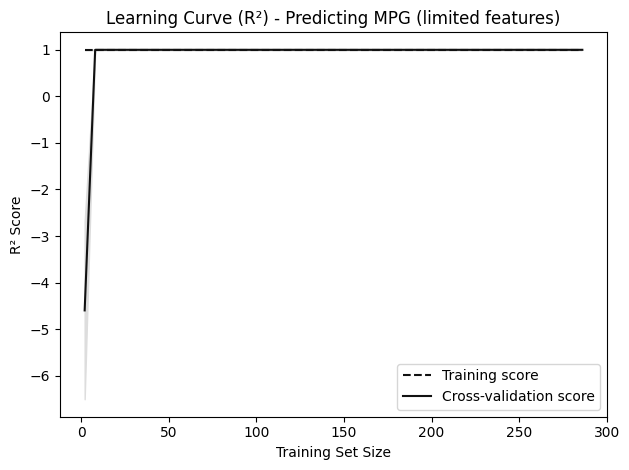

In [57]:
# Plot the data
plt.plot(train_sizes, train_mean, '--', color="#111111", label="Training score")
plt.plot(train_sizes, test_mean,       color="#111111", label="Cross-validation score")

plt.fill_between(train_sizes, train_mean - train_std,
                 train_mean + train_std, color="#DDDDDD")
plt.fill_between(train_sizes, test_mean - test_std,
                 test_mean + test_std, color="#DDDDDD")

plt.title("Learning Curve (R²) - Predicting MPG (limited features)")
plt.xlabel("Training Set Size"), plt.ylabel("R² Score")
plt.legend(loc="best")
plt.tight_layout()
plt.show()